# Bepaling van warmtecapaciteit van een onbekend materiaal

**Auteur:** Freek Pols  
**Laatste update:** 3 december 2025


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter-experiment. 

We verwarmen een massa van het materiaal tot een bekende temperatuur en plaatsen het daarna in water met een bekende massa en temperatuur. Door de eindtemperatuur van het water te meten kunnen we de soortelijke warmte van het onbekende materiaal berekenen.


# Theorie

De soortelijke warmte $$c$$ van een materiaal is gedefinieerd als de hoeveelheid warmte $$Q$$ die nodig is om de temperatuur $$T$$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
c = \frac{Q}{m \Delta T} \tag{eq:heat_capacity}
$$

Waarbij $$Q$$ de hoeveelheid warmte in Joules is, $$m$$ de massa in kilogram is en $$\Delta T$$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
Q_{\text{materiaal}} = -Q_{\text{water}} \tag{eq:black}
$$

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen \((\text{eq:heat_capacity})\) en \((\text{eq:black})\) om de volgende vergelijking te krijgen:

$$
T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m} \tag{eq:combined}
$$

Waarbij de subscripts $$b$$ en $$e$$ respectievelijk staan voor begintoestand en eindtoestand, $$w$$ voor water en $$m$$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp

De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.


## Materialen

Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker

```{figure} figures/c_onbekend_setup.jpg
:width: 70%
:label: fig_c_onbekend_setup

Een schematische weergave van de opstelling



## Procedure

Bespreek wie welke massa's van het onbekende materiaal gaat meten.  
Bespreek ook hoeveel water er gebruikt gaat worden.  
Bepaal de begintemperaturen.  
Hevel het aantal afgesproken massa's in de maatbeker.  
Roer voorzichtig zodat de temperatuur homogeen is.  
Noteer de hoogste gemeten temperatuur, dit is $$T_e$$.  
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.

Hieronder staat een voorbeeld hoe je een grafiek moet opslaan en vervolgens in je document kunt oproepen.
Het voorbeeld kun je natuurlijk straks verwijderen.



# Resultaten


Soortelijke warmte per blokje (J/kg·K):
Blokje 108.8 g: c_m = 404.2 J/kg·K
Blokje 100.0 g: c_m = 472.7 J/kg·K
Blokje 100.6 g: c_m = 537.6 J/kg·K
Blokje 50.2 g: c_m = 496.2 J/kg·K
Blokje 50.0 g: c_m = 443.4 J/kg·K
Blokje 100.0 g: c_m = 189.5 J/kg·K
Blokje 51.1 g: c_m = 512.9 J/kg·K

Gemiddelde soortelijke warmte: 436.7 ± 108.9 J/kg·K


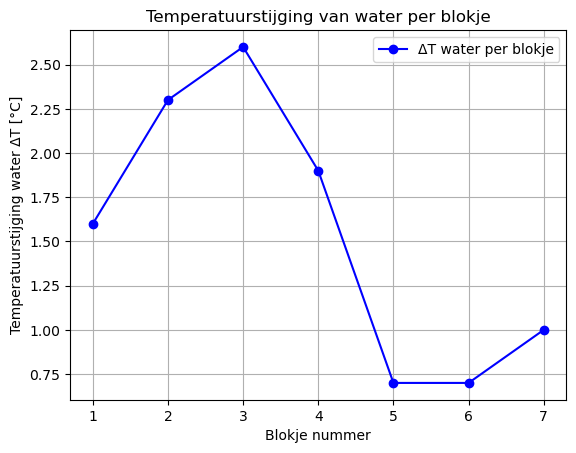

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Gegeven data
deltaT = np.array([1.6, 2.3, 2.6, 1.9, 0.7, 0.7, 1.0])          # ΔT water in °C
Mw = np.array([307.3, 218, 229.1, 137.5, 331.08, 283.24, 296.8]) / 1000  # kg
Mblokje = np.array([108.8, 100, 100.6, 50.2, 49.95, 100, 51.1]) / 1000    # kg
Tbegin = np.array([69, 67, 69, 67, 67, 67, 69])        # °C, temperatuur blokje
Twater = np.array([20.6, 20.3, 20.3, 21.2, 22.5, 22.5, 20.6])  # °C, temperatuur water

# Soortelijke warmte water
cw = 4186  # J/kg·K

# Berekening soortelijke warmte van elk blokje
cm = (cw * Mw * deltaT) / (Mblokje * (Tbegin - Twater - deltaT))

# Gemiddelde en standaardafwijking
cm_mean = np.mean(cm)
cm_std = np.std(cm)

# Print resultaten per blokje
print("Soortelijke warmte per blokje (J/kg·K):")
for massa, val in zip(Mblokje*1000, cm):
    print(f"Blokje {massa:.1f} g: c_m = {val:.1f} J/kg·K")

# Print gemiddelde
print(f"\nGemiddelde soortelijke warmte: {cm_mean:.1f} ± {cm_std:.1f} J/kg·K")

# grafiek deltaT per blokje
plt.figure()
plt.plot(np.arange(1, len(deltaT)+1), deltaT, 'bo-', label='ΔT water per blokje')
plt.xlabel('Blokje nummer')
plt.ylabel('Temperatuurstijging water ΔT [°C]')
plt.title('Temperatuurstijging van water per blokje')
plt.grid(True)
plt.xticks(np.arange(1, len(deltaT)+1))
plt.legend()
plt.show()

blokjes_info = [
    "Blokje 1: 108.8 g",
    "Blokje 2: 100.0 g",
    "Blokje 3: 100.6 g",
    "Blokje 4: 50.2 g",
    "Blokje 5: 49.95 g",
    "Blokje 6: 100.0 g",
    "Blokje 7: 51.1 g"
]




# Discussie en conclusie

**Discussie:**  
We hebben de soortelijke warmte van een onbekend materiaal bepaald door blokjes van verschillende massa's in heet water te verwarmen en vervolgens in een bekend volume water te plaatsen. Door de temperatuurstijging van het water (ΔT) te meten konden we voor elk blokje de soortelijke warmte berekenen

De berekende soortelijke warmte per blokje varieerde tussen ongeveer 190 en 540 J/kg·K. Het gemiddelde van alle blokjes is **437 J/kg·K** met een standaardafwijking van ±109 J/kg·K. De verschillen tussen de blokjes zijn waarschijnlijk te verklaren door kleine meetfouten, warmteverlies aan de omgeving, of het niet volledig homogeen mengen van het water en het blokje

**Conclusie:**  
Het onbekende materiaal heeft een soortelijke warmte van ongeveer **437 ± 109 J/kg·K**, wat wijst op een materiaal dat warmte relatief matig kan opslaan, vergelijbaar met metalen zoals koper of aluminium. Het gemiddelde geeft een goede indicatie van het materiaal, ondanks kleine afwijkingen tussen de blokjes
